## DS2000 & DS2001 Programming with Data & Practicum

# Lab 7: Simulations and Random Samples

#### Today's lab

Welcome to Lab 7! In today's lab, you'll continue practicing simulation and random sampling.

Reading:

* [9.3 Simulations](https://www.inferentialthinking.com/chapters/09/3/Simulation.html)
* [10. Sampling](https://inferentialthinking.com/chapters/10/Sampling_and_Empirical_Distributions.html)

First, set up the tests and imports by running the cell below.

In [1]:
# Don't change this cell; just run it. 

import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

import otter
grader = otter.Notebook("lab07.ipynb")

## 1. Roulette

A Nevada roulette wheel has 38 pockets and a small ball that rests on the wheel. When the wheel is spun, the ball comes to rest in one of the 38 pockets. That pocket is declared the winner. 

The pockets are labeled 0, 00, 1, 2, 3, 4, ... , 36. Pockets 0 and 00 are green, and the other pockets are alternately red and black. The table `wheel` is a representation of a Nevada roulette wheel. Note that *both* columns consist of **strings**. Below is an example of a roulette wheel!

<img src="roulette_wheel.jpeg" width="330px">

In [2]:
wheel = Table.read_table('roulette_wheel.csv', dtype=str)
wheel

Pocket,Color
00,green
0,green
1,red
2,black
3,red
4,black
5,red
6,black
7,red
8,black


### Betting on Red ###
If you bet on *red*, you are betting that the winning pocket will be red. This bet *pays 1 to 1*. That means if you place a one-dollar bet on red, then:

- If the winning pocket is red, you gain 1 dollar. That is, you get your original dollar back, plus one more dollar.
- if the winning pocket is not red, you lose your dollar. In other words, you gain -1 dollars.

Let's see if you can make money by betting on red at roulette.

**Question 1.1.** Define a function `dollar_bet_on_red` that takes the name of a color and returns your gain in dollars if that color had won and you had placed a one-dollar bet on red. Remember that the gain can be negative. Make sure your function returns an integer. 

You can assume that the only colors that will be passed as arguments are red, black, and green. Your function doesn't have to check that.

In [3]:
def dollar_bet_on_red(x):
    if x == "red":
        return 1
    else:
        return -1

In [4]:
grader.check("q11")

q11 results: All test cases passed!

Run the cell below to make sure your function is working.

In [5]:
print(dollar_bet_on_red('green'))
print(dollar_bet_on_red('black'))
print(dollar_bet_on_red('red'))

-1
-1
1


**Question 1.2.** Add a column labeled `Winnings: Red` to the table `wheel`. For each pocket, the column should contain your gain in dollars if that pocket won and you had bet one dollar on red. 

*Hint:* Your code should use(apply) the function `dollar_bet_on_red`.

*Hint:*  Table 1 displays the expected output.

In [6]:
red_winnings = wheel.apply(dollar_bet_on_red, "Color")
wheel = wheel.with_column("Winnings: Red", red_winnings)
wheel

Pocket,Color,Winnings: Red
00,green,-1
0,green,-1
1,red,1
2,black,-1
3,red,1
4,black,-1
5,red,1
6,black,-1
7,red,1
8,black,-1


In [7]:
grader.check("q12")

q12 results: All test cases passed!

Table 1:

<img src="Q1.2_table.PNG">

### Random Samples

One way to draw a random sample from a table is by calling `tbl.sample(n)` which creates a new table with `n` rows which are randomly sampled from the original table (this is done with replacement; so it is possible to see the same row multiple times in the new table).

Run the following cell which draws a random sample of 5 rows.  Run it a few times to see how the sample changes.

In [12]:
wheel.sample(5)

Pocket,Color,Winnings: Red
34,red,1
27,red,1
24,black,-1
18,red,1
0,green,-1


### Simulating 10 bets on Red
Roulette wheels are set up so that each time they are spun, the winning pocket is equally likely to be any of the 38 pockets regardless of the results of all other spins. Let's see what would happen if we decided to bet one dollar on red each round.

**Question 1.3.** Create a table `ten_bets` by sampling the table `wheel` to simulate 10 spins of the roulette wheel. Your table should have the same three column labels as in `wheel`. Once you've created that table, set `sum_bets` to your net gain in all 10 bets, assuming that you bet one dollar on red each time. 

*Hint:* It may be helpful to print out `ten_bets` after you create it!

In [16]:
ten_bets = wheel.sample(10)
sum_bets = sum(ten_bets.column('Winnings: Red'))
sum_bets

-2

In [17]:
grader.check("q13")

q13 results: All test cases passed!

Run the cells above a few times to see how much money you would make if you made 10 one-dollar bets on red. Making a negative amount of money doesn't feel good, but it is a reality in gambling. Casinos are a business, and they make money when gamblers lose.

**Question 1.4.** Let's see what would happen if you made more bets. Define a function `net_gain_red` that takes the number of bets and returns the net gain in that number of one-dollar bets on red.

*Hint:* You should use your `wheel` table within your function definition.

In [18]:
def net_gain_red(bets):
     return sum(wheel.sample(bets).column("Winnings: Red"))

In [19]:
grader.check("q14")

q14 results: All test cases passed!

Run the cell below a few times to make sure that the results are similar to those you observed in the previous exercise.

In [22]:
net_gain_red(10)

0

**Question 1.5.** Complete the cell below to simulate the net gain in 200 one-dollar bets on red, repeating the process 10,000 times. After the cell is run, `all_gains_red` should be an array with 10,000 entries, each of which is the net gain in 200 one-dollar bets on red. 

For a refresher on the steps involved in doing a simulation, read [9.3 Simulation](https://inferentialthinking.com/chapters/09/3/Simulation.html)

In [23]:
num_bets = 200
repetitions = 10000

all_gains_red = make_array()

for i in np.arange(repetitions):
    all_gains_red = np.append(all_gains_red, net_gain_red(num_bets))

len(all_gains_red) # Do not change this line! Check that all_gains_red is length 10000.

10000

In [24]:
grader.check("q15")

q15 results: All test cases passed!

Run the cell below to visualize the results of your simulation.

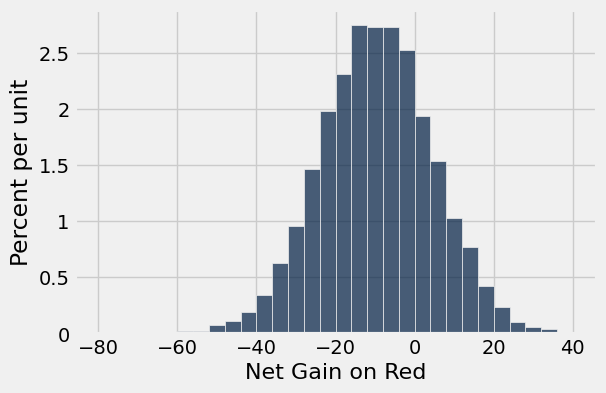

In [25]:
gains = Table().with_columns('Net Gain on Red', all_gains_red)
gains.hist(bins = np.arange(-80, 41, 4))

**Question 1.6:** Using the histogram above, decide whether the following statement is true or false:

>If you make 200 one-dollar bets on red, your chance of losing money is more than 50%.

Assign `loss_more_than_50` to either `True` or `False` depending on your answer to the question.

In [26]:
loss_more_than_50 = False

In [27]:
grader.check("q16")

q1_6 results: All test cases passed!

### Betting on a Split ###
If betting on red doesn't seem like a good idea, maybe a gambler might want to try a different bet. A bet on a *split* is a bet on two consecutive numbers such as 5 and 6. This bet pays 17 to 1. That means if you place a one-dollar bet on the split 5 and 6, then:

- If the winning pocket is either 5 or 6, your gain is 17 dollars.
- If any other pocket wins, you lose your dollar, so your gain is -1 dollars.

**Question 1.7.** Define a function `dollar_bet_on_split` that takes a pocket winning number and returns your gain in dollars if you had bet one dollar on the 5-6 split. 

*Hint:* Remember that the pockets are represented as strings.

In [28]:
def dollar_bet_on_split(pock_num):
    if pock_num == "5":
        return 17
    elif pock_num == "6":
        return 17
    else:
        return -1

In [29]:
grader.check("q17")

q17 results: All test cases passed!

Run the cell below to check that your function is doing what it should.

In [30]:
print(dollar_bet_on_split('5'))   # pocket winning number is '5'
print(dollar_bet_on_split('6'))   # pocket winning number is '6'
print(dollar_bet_on_split('00'))  # pocket winning number is '00'
print(dollar_bet_on_split('23'))  # pocket winning number is '23'

17
17
-1
-1


**Question 1.8.** Add a column `Winnings: Split` to the `wheel` table. For each pocket, the column should contain your gain in dollars if that pocket won and you had bet one dollar on the 5-6 split. 

*Hint:* Table 2 displays the expected output.

In [31]:
split_winnings = wheel.apply(dollar_bet_on_split, "Pocket")
wheel = wheel.with_column("Winnings: Split", split_winnings)
wheel.show(10) # Do not change this line.

Pocket,Color,Winnings: Red,Winnings: Split
00,green,-1,-1
0,green,-1,-1
1,red,1,-1
2,black,-1,-1
3,red,1,-1
4,black,-1,-1
5,red,1,17
6,black,-1,17
7,red,1,-1
8,black,-1,-1


In [32]:
grader.check("q18")

q18 results: All test cases passed!

Table 2:

<img src="Q1.8_table.PNG">

**Question 1.9.** Simulate the net gain in 200 one-dollar bets on the 5-6 split, repeating the process 10,000 times and saving your gains in the array `all_gains_split`. 

*Hint:* Your code in Questions 1.4 and 1.5 may be helpful here!

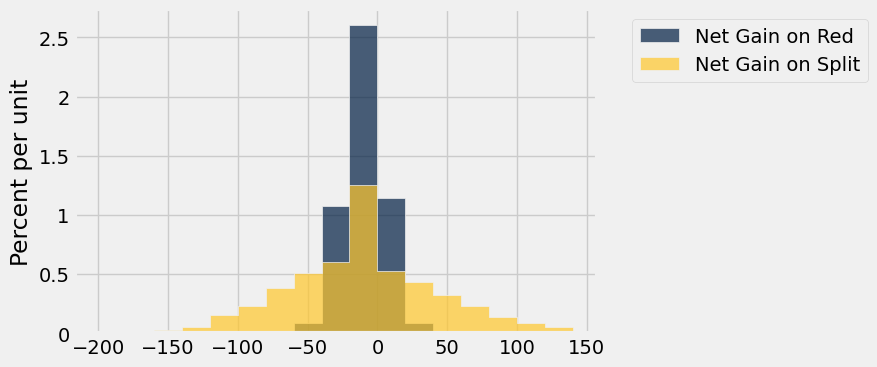

In [33]:
num_bets = 200 
repetitions = 10000

all_gains_split = make_array() 

for i in np.arange(repetitions):
    all_gains_split = np.append(all_gains_split, sum(wheel.sample(num_bets).column(
        "Winnings: Split")))

# Do not change the two lines below
gains = gains.with_columns('Net Gain on Split', all_gains_split)
gains.hist(bins = np.arange(-200, 150, 20))

In [34]:
grader.check("q19")

q19 results: All test cases passed!

**Question 1.10.** Look carefully at the histograms above and say whether each of the following statements is `True` or `False`. 

1. If you bet one dollar 200 times on a split, your chance of losing money is more than 50%.
2. If you bet one dollar 200 times in roulette, your chance of making more than 50 dollars is greater if you bet on a split each time than if you bet on red each time.
3. If you bet one dollar 200 times in roulette, your chance of losing more than 50 dollars is greater if you bet on a split each time than if you bet on red each time.

Assign the `histogram_statements` to an array of statement number(s) that corresponding to `True` statements.

*Hint:* We've already seen one of these statements in a prior question.

In [35]:
histogram_statements = make_array(1, 2, 3)

In [36]:
grader.check("q110")

q110 results: All test cases passed!

If this exercise has put you off playing roulette, it has done its job. If you are still curious about other bets, [here](https://en.wikipedia.org/wiki/Roulette#Bet_odds_table) they all are, and [here](https://en.wikipedia.org/wiki/Roulette#House_edge) is the bad news. The house – that is, the casino – always has an edge over the gambler.

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [37]:
grader.check_all()

q11 results: All test cases passed!

q110 results: All test cases passed!

q12 results: All test cases passed!

q13 results: All test cases passed!

q14 results: All test cases passed!

q15 results: All test cases passed!

q1_6 results: All test cases passed!

q17 results: All test cases passed!

q18 results: All test cases passed!

q19 results: All test cases passed!

**Congratulations, you're done with Lab 7!**

Be sure to:
- **run** all the tests 
- **save** your notebook and **download** a pdf version of it,
- **submit** your work to Gradescope.